In [1]:
import scanpy as sc
import pandas as pd
import numpy as np
import logging
import os
from pathlib import Path
import anndata2ri
from bokeh.models import TabPanel, Tabs,ColorBar
from bokeh.plotting import show, output_file
from scipy.stats import median_abs_deviation
import seaborn as sns
import scrublet as scr
import seaborn as sns
import rpy2.rinterface_lib.callbacks as rcb
import rpy2.robjects as ro
from utils import interactive_embedding
import anndata as ad

%matplotlib inline


In [2]:
sample_path = Path("../data/blood/QC")

sample_list = []

sum_cells = 0
sum_genes = []
for sample in os.listdir(sample_path):
    if os.path.splitext(sample)[1] == '.h5ad':
        adata_sample = sc.read(sample_path / sample)
        adata_sample.obs['pt'] = '-'.join(sample.split('-')[:2])
        adata_sample.obs['side'] = sample.split('-')[3].split("_")[0]
        sum_genes.extend(list(adata_sample.var.index))
        print(sample, adata_sample.shape, "\n")
        sample_list.append(adata_sample)
        sum_cells += adata_sample.shape[0]


PT-185-blood-L_QC_normalization.h5ad (6644, 15633) 

PT-206-blood-L_QC_normalization.h5ad (258, 12682) 

PT-214-blood-R_QC_normalization.h5ad (1058, 15152) 

PT-205-blood-R_QC_normalization.h5ad (590, 13307) 

PT-201-blood-L_QC_normalization.h5ad (441, 12989) 

PT-208-blood-L_QC_normalization.h5ad (504, 13510) 

PT-203-blood-R_QC_normalization.h5ad (3522, 18689) 

PT-212-blood-R_QC_normalization.h5ad (1749, 14728) 

PT-212-blood-L_QC_normalization.h5ad (371, 14076) 

PT-203-blood-L_QC_normalization.h5ad (547, 14509) 

PT-208-blood-R_QC_normalization.h5ad (81, 4076) 

PT-182-blood-R_QC_normalization.h5ad (3486, 15210) 

PT-205-blood-L_QC_normalization.h5ad (291, 12516) 

PT-214-blood-L_QC_normalization.h5ad (4365, 16687) 



In [3]:
sum_cells, len(pd.unique(sum_genes))

(23907, 20421)

In [4]:
adata_b1 = ad.concat(sample_list, join="outer",  index_unique="_")
adata_b1.obs_names_make_unique()
adata_b1.X

<23907x20421 sparse matrix of type '<class 'numpy.float64'>'
	with 34258470 stored elements in Compressed Sparse Row format>

In [ ]:
del sample_list

### Remove doublets

In [5]:
#Remove doublets
# adata_b1 = adata_b1[adata_b1.obs['predicted_doublets_scrublet'] == False,:]
# adata_b1[adata_b1.obs['predicted_doublets_scrublet'] & adata_b1[adata_b1.obs['predicted_doublets_scrublet']
print(len(set(adata_b1.obs[adata_b1.obs["scDblFinder_class"]=='singlet'].index).intersection(adata_b1.obs[adata_b1.obs['predicted_doublets_scrublet']==False].index)))
print(len(set(adata_b1.obs[adata_b1.obs["scDblFinder_class"]=='singlet'].index)), len(set(adata_b1.obs[adata_b1.obs["predicted_doublets_scrublet"]==False].index)) )
adata_b1 = adata_b1[(adata_b1.obs["scDblFinder_class"]=='singlet') & (adata_b1.obs['predicted_doublets_scrublet']==False)]
adata_b1

22764


View of AnnData object with n_obs × n_vars = 22764 × 20421
    obs: 'n_genes', 'n_genes_by_counts', 'log1p_n_genes_by_counts', 'total_counts', 'log1p_total_counts', 'pct_counts_in_top_20_genes', 'total_counts_mt', 'log1p_total_counts_mt', 'pct_counts_mt', 'total_counts_ribo', 'log1p_total_counts_ribo', 'pct_counts_ribo', 'total_counts_hb', 'log1p_total_counts_hb', 'pct_counts_hb', 'outlier', 'mt_outlier', 'scDblFinder_score', 'scDblFinder_class', 'doublet_scores_scrublet', 'predicted_doublets_scrublet', 'size_factors', 'pt', 'side'
    obsm: 'X_pca', 'X_umap'
    layers: 'counts', 'log1p_norm', 'scran_normalization', 'soupX_counts'

### Filter mito genes

In [6]:
mito_genes = adata_b1.var_names.str.startswith('MT-')
keep = np.invert(mito_genes)

adata_b1 = adata_b1[:,keep]
adata_b1

View of AnnData object with n_obs × n_vars = 22764 × 20408
    obs: 'n_genes', 'n_genes_by_counts', 'log1p_n_genes_by_counts', 'total_counts', 'log1p_total_counts', 'pct_counts_in_top_20_genes', 'total_counts_mt', 'log1p_total_counts_mt', 'pct_counts_mt', 'total_counts_ribo', 'log1p_total_counts_ribo', 'pct_counts_ribo', 'total_counts_hb', 'log1p_total_counts_hb', 'pct_counts_hb', 'outlier', 'mt_outlier', 'scDblFinder_score', 'scDblFinder_class', 'doublet_scores_scrublet', 'predicted_doublets_scrublet', 'size_factors', 'pt', 'side'
    obsm: 'X_pca', 'X_umap'
    layers: 'counts', 'log1p_norm', 'scran_normalization', 'soupX_counts'

In [7]:
sc.pp.normalize_total(adata_b1)
sc.pp.log1p(adata_b1)
sc.pp.highly_variable_genes(
    adata_b1, layer='counts', n_top_genes=5000, flavor="seurat_v3", batch_key='pt'
)
sc.pp.pca(adata_b1, svd_solver="arpack")


/Users/nicolebussola/anaconda3/envs/LBP_QC/lib/python3.8/site-packages/scanpy/preprocessing/_normalization.py:170: UserWarning: Received a view of an AnnData. Making a copy.
  view_to_actual(adata)


In [8]:
# n_batches = adata_b1.var["highly_variable_nbatches"].value_counts()
# ax = n_batches.plot(kind="bar")
# n_batches

In [9]:
sc.pp.neighbors(adata_b1)
sc.tl.umap(adata_b1)


/Users/nicolebussola/anaconda3/envs/LBP_QC/lib/python3.8/site-packages/umap/distances.py:1063: NumbaDeprecationWarning: The 'nopython' keyword argument was not supplied to the 'numba.jit' decorator. The implicit default value for this argument is currently False, but it will be changed to True in Numba 0.59.0. See https://numba.readthedocs.io/en/stable/reference/deprecation.html#deprecation-of-object-mode-fall-back-behaviour-when-using-jit for details.
  @numba.jit()
/Users/nicolebussola/anaconda3/envs/LBP_QC/lib/python3.8/site-packages/umap/distances.py:1071: NumbaDeprecationWarning: The 'nopython' keyword argument was not supplied to the 'numba.jit' decorator. The implicit default value for this argument is currently False, but it will be changed to True in Numba 0.59.0. See https://numba.readthedocs.io/en/stable/reference/deprecation.html#deprecation-of-object-mode-fall-back-behaviour-when-using-jit for details.
  @numba.jit()
/Users/nicolebussola/anaconda3/envs/LBP_QC/lib/python3.8

In [10]:
adata_hvg = adata_b1[:, adata_b1.var["highly_variable"]].copy()
adata_hvg

AnnData object with n_obs × n_vars = 22764 × 5000
    obs: 'n_genes', 'n_genes_by_counts', 'log1p_n_genes_by_counts', 'total_counts', 'log1p_total_counts', 'pct_counts_in_top_20_genes', 'total_counts_mt', 'log1p_total_counts_mt', 'pct_counts_mt', 'total_counts_ribo', 'log1p_total_counts_ribo', 'pct_counts_ribo', 'total_counts_hb', 'log1p_total_counts_hb', 'pct_counts_hb', 'outlier', 'mt_outlier', 'scDblFinder_score', 'scDblFinder_class', 'doublet_scores_scrublet', 'predicted_doublets_scrublet', 'size_factors', 'pt', 'side'
    var: 'highly_variable', 'highly_variable_rank', 'means', 'variances', 'variances_norm', 'highly_variable_nbatches'
    uns: 'log1p', 'hvg', 'pca', 'neighbors', 'umap'
    obsm: 'X_pca', 'X_umap'
    varm: 'PCs'
    layers: 'counts', 'log1p_norm', 'scran_normalization', 'soupX_counts'
    obsp: 'distances', 'connectivities'

/Users/nicolebussola/anaconda3/envs/LBP_QC/lib/python3.8/site-packages/scanpy/plotting/_tools/scatterplots.py:392: UserWarning: No data for colormapping provided via 'c'. Parameters 'cmap' will be ignored
  cax = scatter(
/Users/nicolebussola/anaconda3/envs/LBP_QC/lib/python3.8/site-packages/scanpy/plotting/_tools/scatterplots.py:392: UserWarning: No data for colormapping provided via 'c'. Parameters 'cmap' will be ignored
  cax = scatter(
/Users/nicolebussola/anaconda3/envs/LBP_QC/lib/python3.8/site-packages/scanpy/plotting/_tools/scatterplots.py:392: UserWarning: No data for colormapping provided via 'c'. Parameters 'cmap' will be ignored
  cax = scatter(
/Users/nicolebussola/anaconda3/envs/LBP_QC/lib/python3.8/site-packages/scanpy/plotting/_tools/scatterplots.py:392: UserWarning: No data for colormapping provided via 'c'. Parameters 'cmap' will be ignored
  cax = scatter(


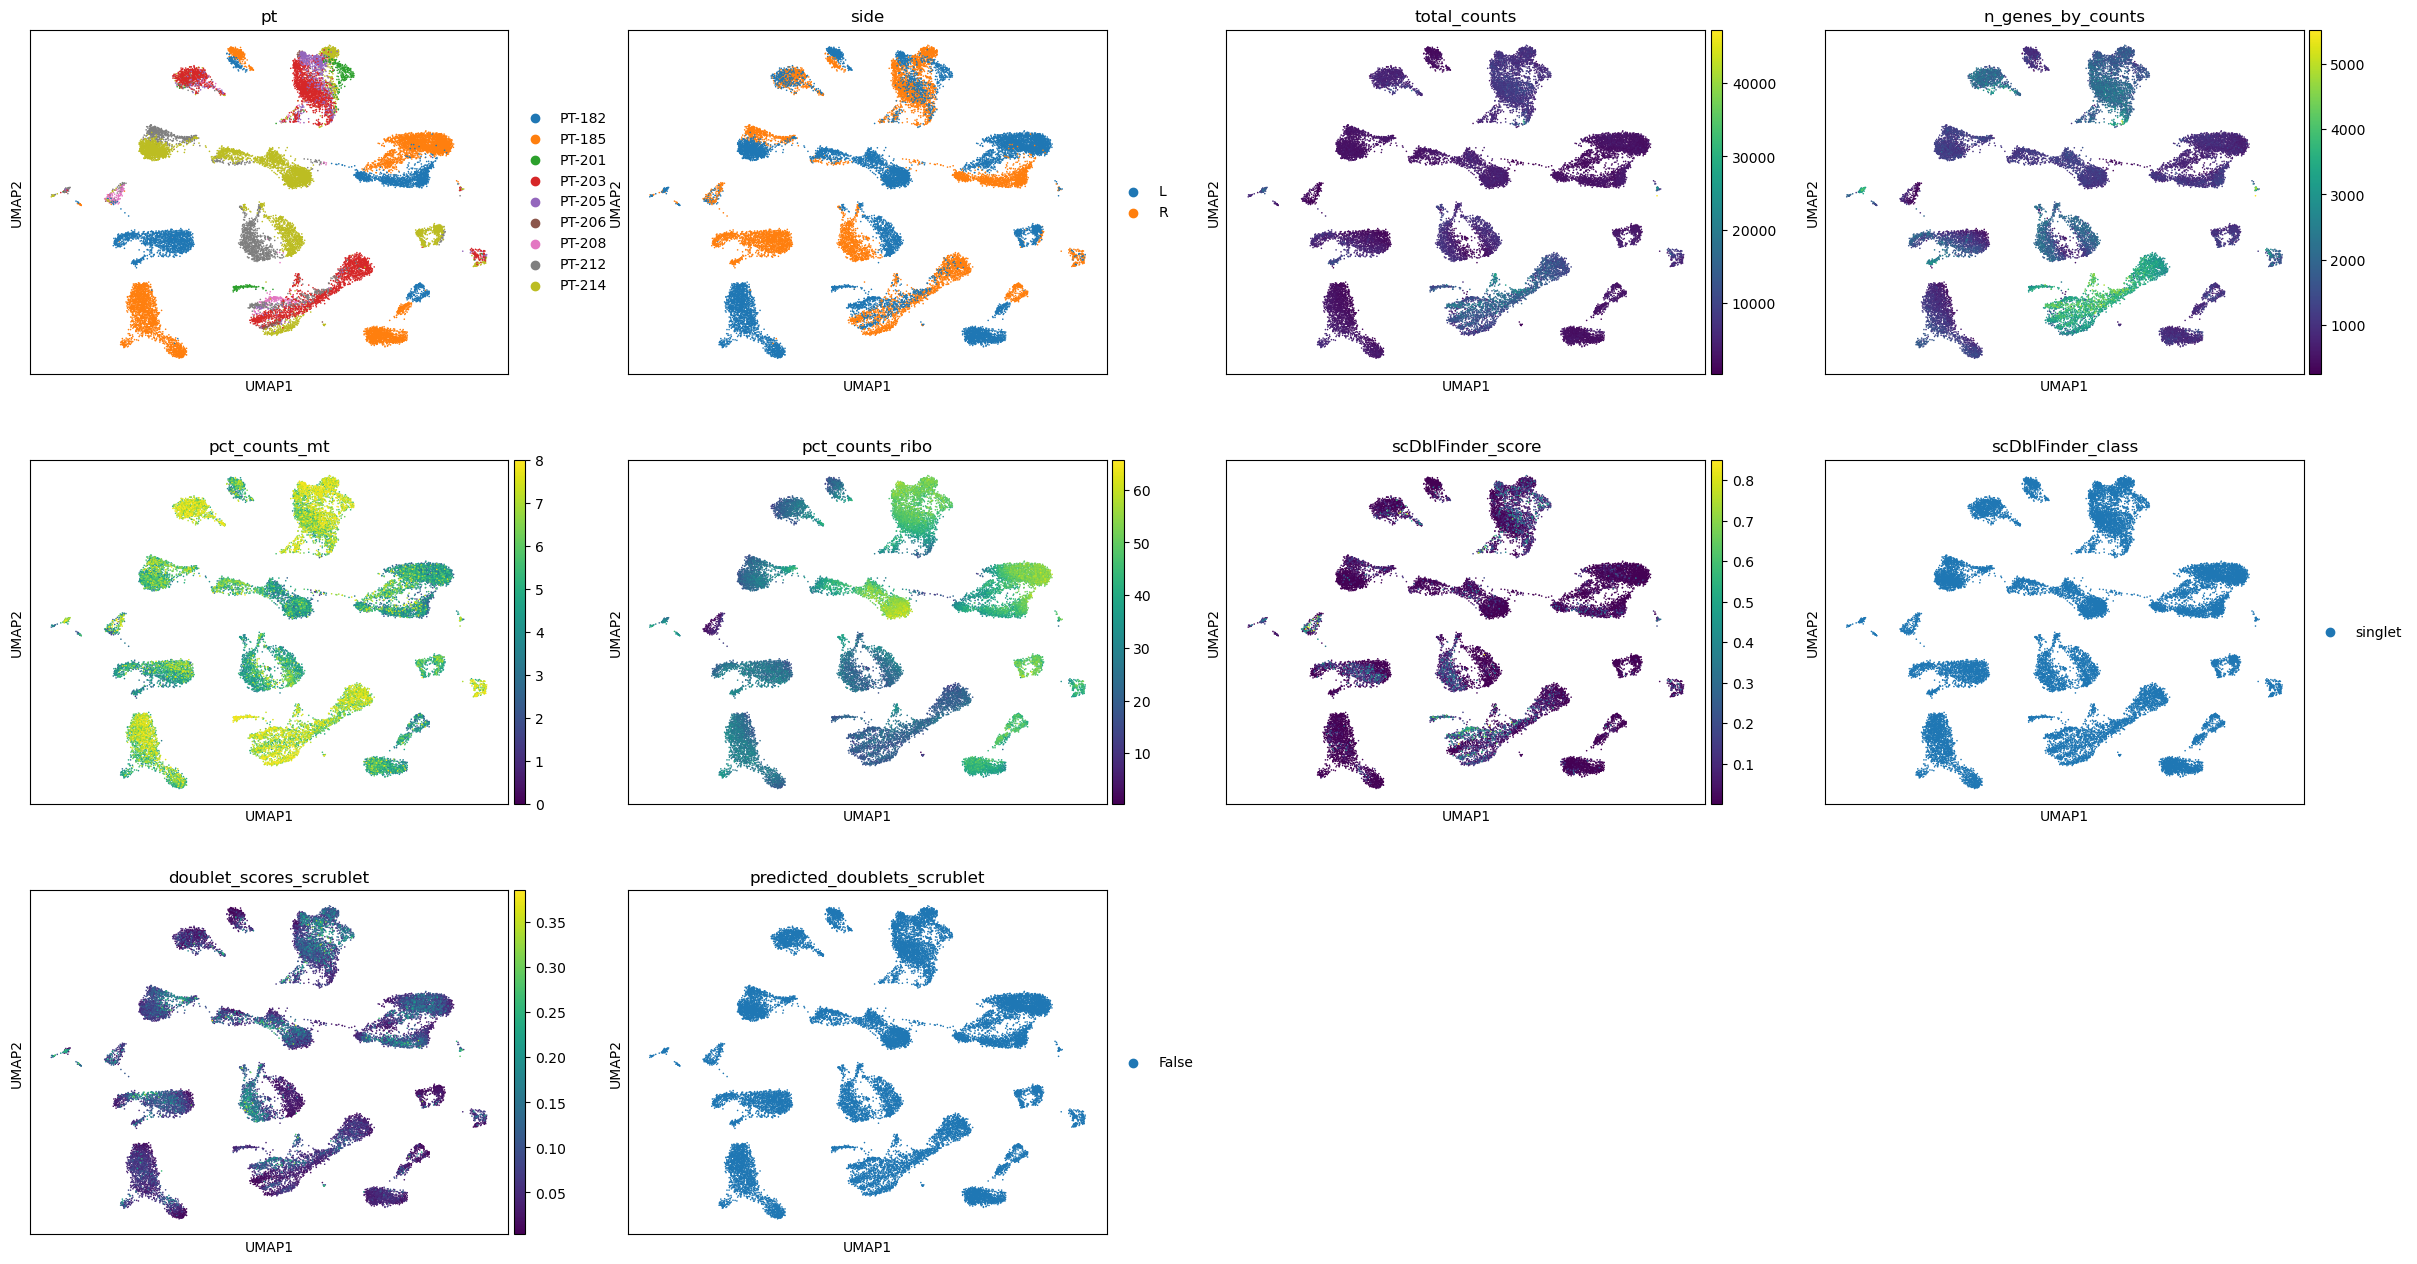

In [12]:
%matplotlib inline
adata_hvg.obs['scDblFinder_class'] = adata_hvg.obs['scDblFinder_class'].astype('str')
adata_hvg.obs['predicted_doublets_scrublet'] =adata_hvg.obs['predicted_doublets_scrublet'].astype('str')

labels = ['pt','side',"total_counts", "n_genes_by_counts", "pct_counts_mt", 'pct_counts_ribo', 'scDblFinder_score','scDblFinder_class','doublet_scores_scrublet', 'predicted_doublets_scrublet']
sc.pl.umap(adata_hvg, color=labels)
tabs = []



In [ ]:
## REMOVE MT GENES

## Data integration

In [13]:
import scvi
scvi.model.SCVI.setup_anndata(adata_hvg, layer="counts", batch_key="pt")
model_scvi = scvi.model.SCVI(adata_hvg)


Global seed set to 0
/Users/nicolebussola/anaconda3/envs/LBP_QC/lib/python3.8/site-packages/flax/struct.py:132: FutureWarning: jax.tree_util.register_keypaths is deprecated, and will be removed in a future release. Please use `register_pytree_with_keys()` instead.
  jax.tree_util.register_keypaths(data_clz, keypaths)
/Users/nicolebussola/anaconda3/envs/LBP_QC/lib/python3.8/site-packages/flax/struct.py:132: FutureWarning: jax.tree_util.register_keypaths is deprecated, and will be removed in a future release. Please use `register_pytree_with_keys()` instead.
  jax.tree_util.register_keypaths(data_clz, keypaths)


In [14]:
# model_scvi.view_anndata_setup()


In [15]:
max_epochs_scvi = np.min([round((20000 / adata_b1.n_obs) * 400), 400])
max_epochs_scvi

351

In [16]:
model_scvi.train(use_gpu=False)


GPU available: False, used: False
TPU available: False, using: 0 TPU cores
IPU available: False, using: 0 IPUs
HPU available: False, using: 0 HPUs


Epoch 351/351: 100%|█████████████████████████████████████████████████████████████████████████████████| 351/351 [1:34:21<00:00, 16.47s/it, loss=1.19e+03, v_num=1]

`Trainer.fit` stopped: `max_epochs=351` reached.


Epoch 351/351: 100%|█████████████████████████████████████████████████████████████████████████████████| 351/351 [1:34:21<00:00, 16.13s/it, loss=1.19e+03, v_num=1]


In [17]:
model_scvi

SCVI Model with the following params: 
n_hidden: 128, n_latent: 10, n_layers: 1, dropout_rate: 0.1, dispersion: gene, gene_likelihood: zinb, 
latent_distribution: normal
Training status: Trained
Model's adata is minified?: False

In [18]:
adata_scvi = adata_hvg.copy()
adata_scvi.obsm["X_scVI"] = model_scvi.get_latent_representation()
sc.pp.neighbors(adata_scvi, use_rep="X_scVI")
sc.tl.umap(adata_scvi)
adata_scvi

AnnData object with n_obs × n_vars = 22764 × 5000
    obs: 'n_genes', 'n_genes_by_counts', 'log1p_n_genes_by_counts', 'total_counts', 'log1p_total_counts', 'pct_counts_in_top_20_genes', 'total_counts_mt', 'log1p_total_counts_mt', 'pct_counts_mt', 'total_counts_ribo', 'log1p_total_counts_ribo', 'pct_counts_ribo', 'total_counts_hb', 'log1p_total_counts_hb', 'pct_counts_hb', 'outlier', 'mt_outlier', 'scDblFinder_score', 'scDblFinder_class', 'doublet_scores_scrublet', 'predicted_doublets_scrublet', 'size_factors', 'pt', 'side', '_scvi_batch', '_scvi_labels'
    var: 'highly_variable', 'highly_variable_rank', 'means', 'variances', 'variances_norm', 'highly_variable_nbatches'
    uns: 'log1p', 'hvg', 'pca', 'neighbors', 'umap', 'pt_colors', 'side_colors', 'scDblFinder_class_colors', 'predicted_doublets_scrublet_colors', '_scvi_uuid', '_scvi_manager_uuid'
    obsm: 'X_pca', 'X_umap', 'X_scVI'
    varm: 'PCs'
    layers: 'counts', 'log1p_norm', 'scran_normalization', 'soupX_counts'
    obsp: '

In [19]:
# adata_scvi.write("../data/blood/blood_scvi_integration.h5ad")

/Users/nicolebussola/anaconda3/envs/LBP_QC/lib/python3.8/site-packages/scanpy/plotting/_tools/scatterplots.py:392: UserWarning: No data for colormapping provided via 'c'. Parameters 'cmap' will be ignored
  cax = scatter(


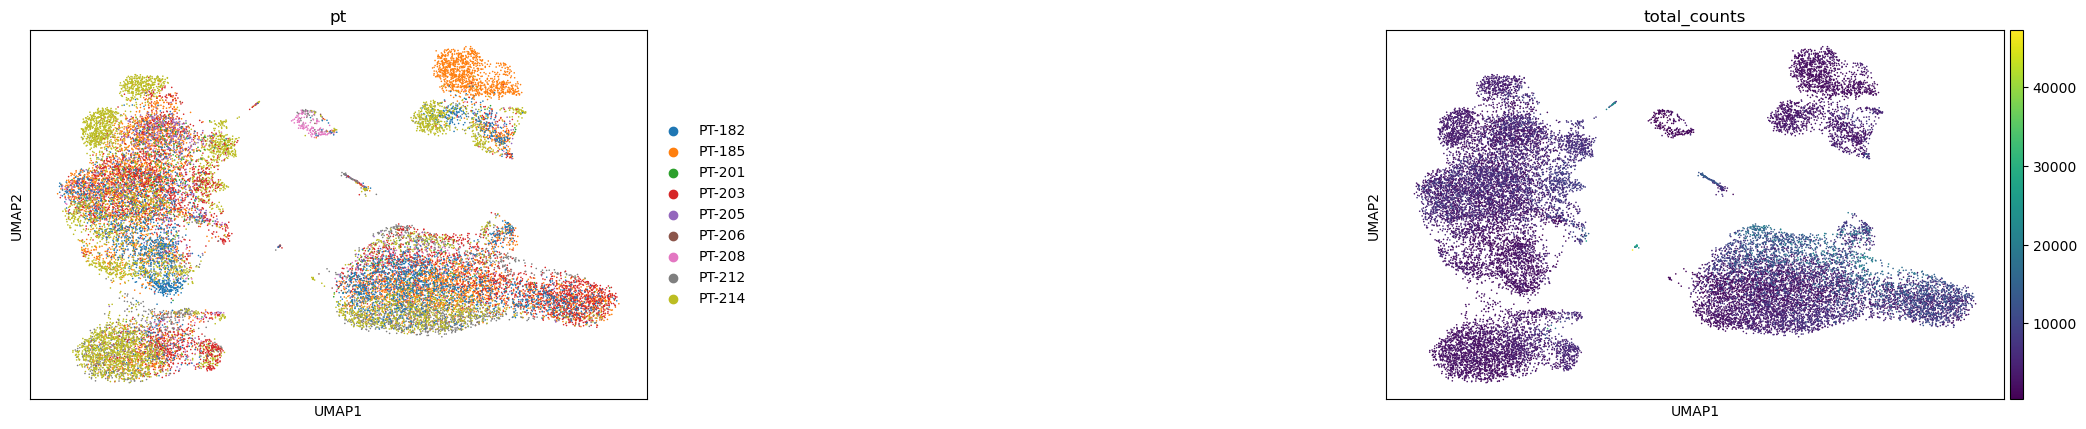

In [20]:
sc.pl.umap(adata_scvi, color=['pt', 'total_counts'], wspace=1)


2023-08-01 11:27:16,875 - harmonypy - INFO - Computing initial centroids with sklearn.KMeans...
2023-08-01 11:27:25,190 - harmonypy - INFO - sklearn.KMeans initialization complete.
2023-08-01 11:27:25,270 - harmonypy - INFO - Iteration 1 of 10
2023-08-01 11:27:29,514 - harmonypy - INFO - Iteration 2 of 10
2023-08-01 11:27:33,592 - harmonypy - INFO - Iteration 3 of 10
2023-08-01 11:27:36,447 - harmonypy - INFO - Converged after 3 iterations
/Users/nicolebussola/anaconda3/envs/LBP_QC/lib/python3.8/site-packages/scanpy/plotting/_tools/scatterplots.py:392: UserWarning: No data for colormapping provided via 'c'. Parameters 'cmap' will be ignored
  cax = scatter(


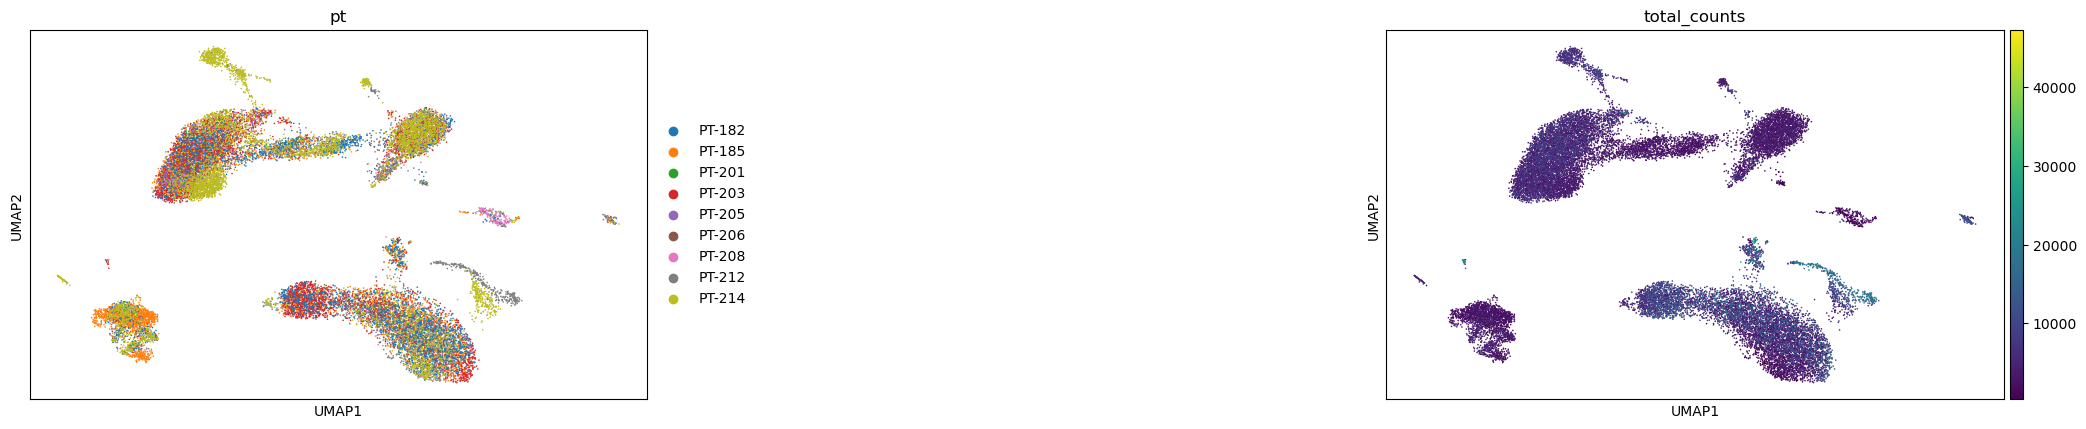

In [21]:
import scanpy.external as sce
adata_harmony = adata_hvg.copy()
sc.pp.pca(adata_harmony, svd_solver="arpack", use_highly_variable=False)

sce.pp.harmony_integrate(adata_harmony, "pt")
sc.pp.neighbors(adata_harmony, use_rep="X_pca_harmony")
sc.tl.umap(adata_harmony)
sc.pl.umap(adata_harmony, color=['pt', 'total_counts'], wspace=1)


In [22]:
# adata_harmony.write("../data/blood/blood_harmony_integration.h5ad")

/Users/nicolebussola/anaconda3/envs/LBP_QC/lib/python3.8/site-packages/scanpy/plotting/_tools/scatterplots.py:392: UserWarning: No data for colormapping provided via 'c'. Parameters 'cmap' will be ignored
  cax = scatter(
/Users/nicolebussola/anaconda3/envs/LBP_QC/lib/python3.8/site-packages/scanpy/plotting/_tools/scatterplots.py:392: UserWarning: No data for colormapping provided via 'c'. Parameters 'cmap' will be ignored
  cax = scatter(
/Users/nicolebussola/anaconda3/envs/LBP_QC/lib/python3.8/site-packages/scanpy/plotting/_tools/scatterplots.py:392: UserWarning: No data for colormapping provided via 'c'. Parameters 'cmap' will be ignored
  cax = scatter(
/Users/nicolebussola/anaconda3/envs/LBP_QC/lib/python3.8/site-packages/scanpy/plotting/_tools/scatterplots.py:392: UserWarning: No data for colormapping provided via 'c'. Parameters 'cmap' will be ignored
  cax = scatter(


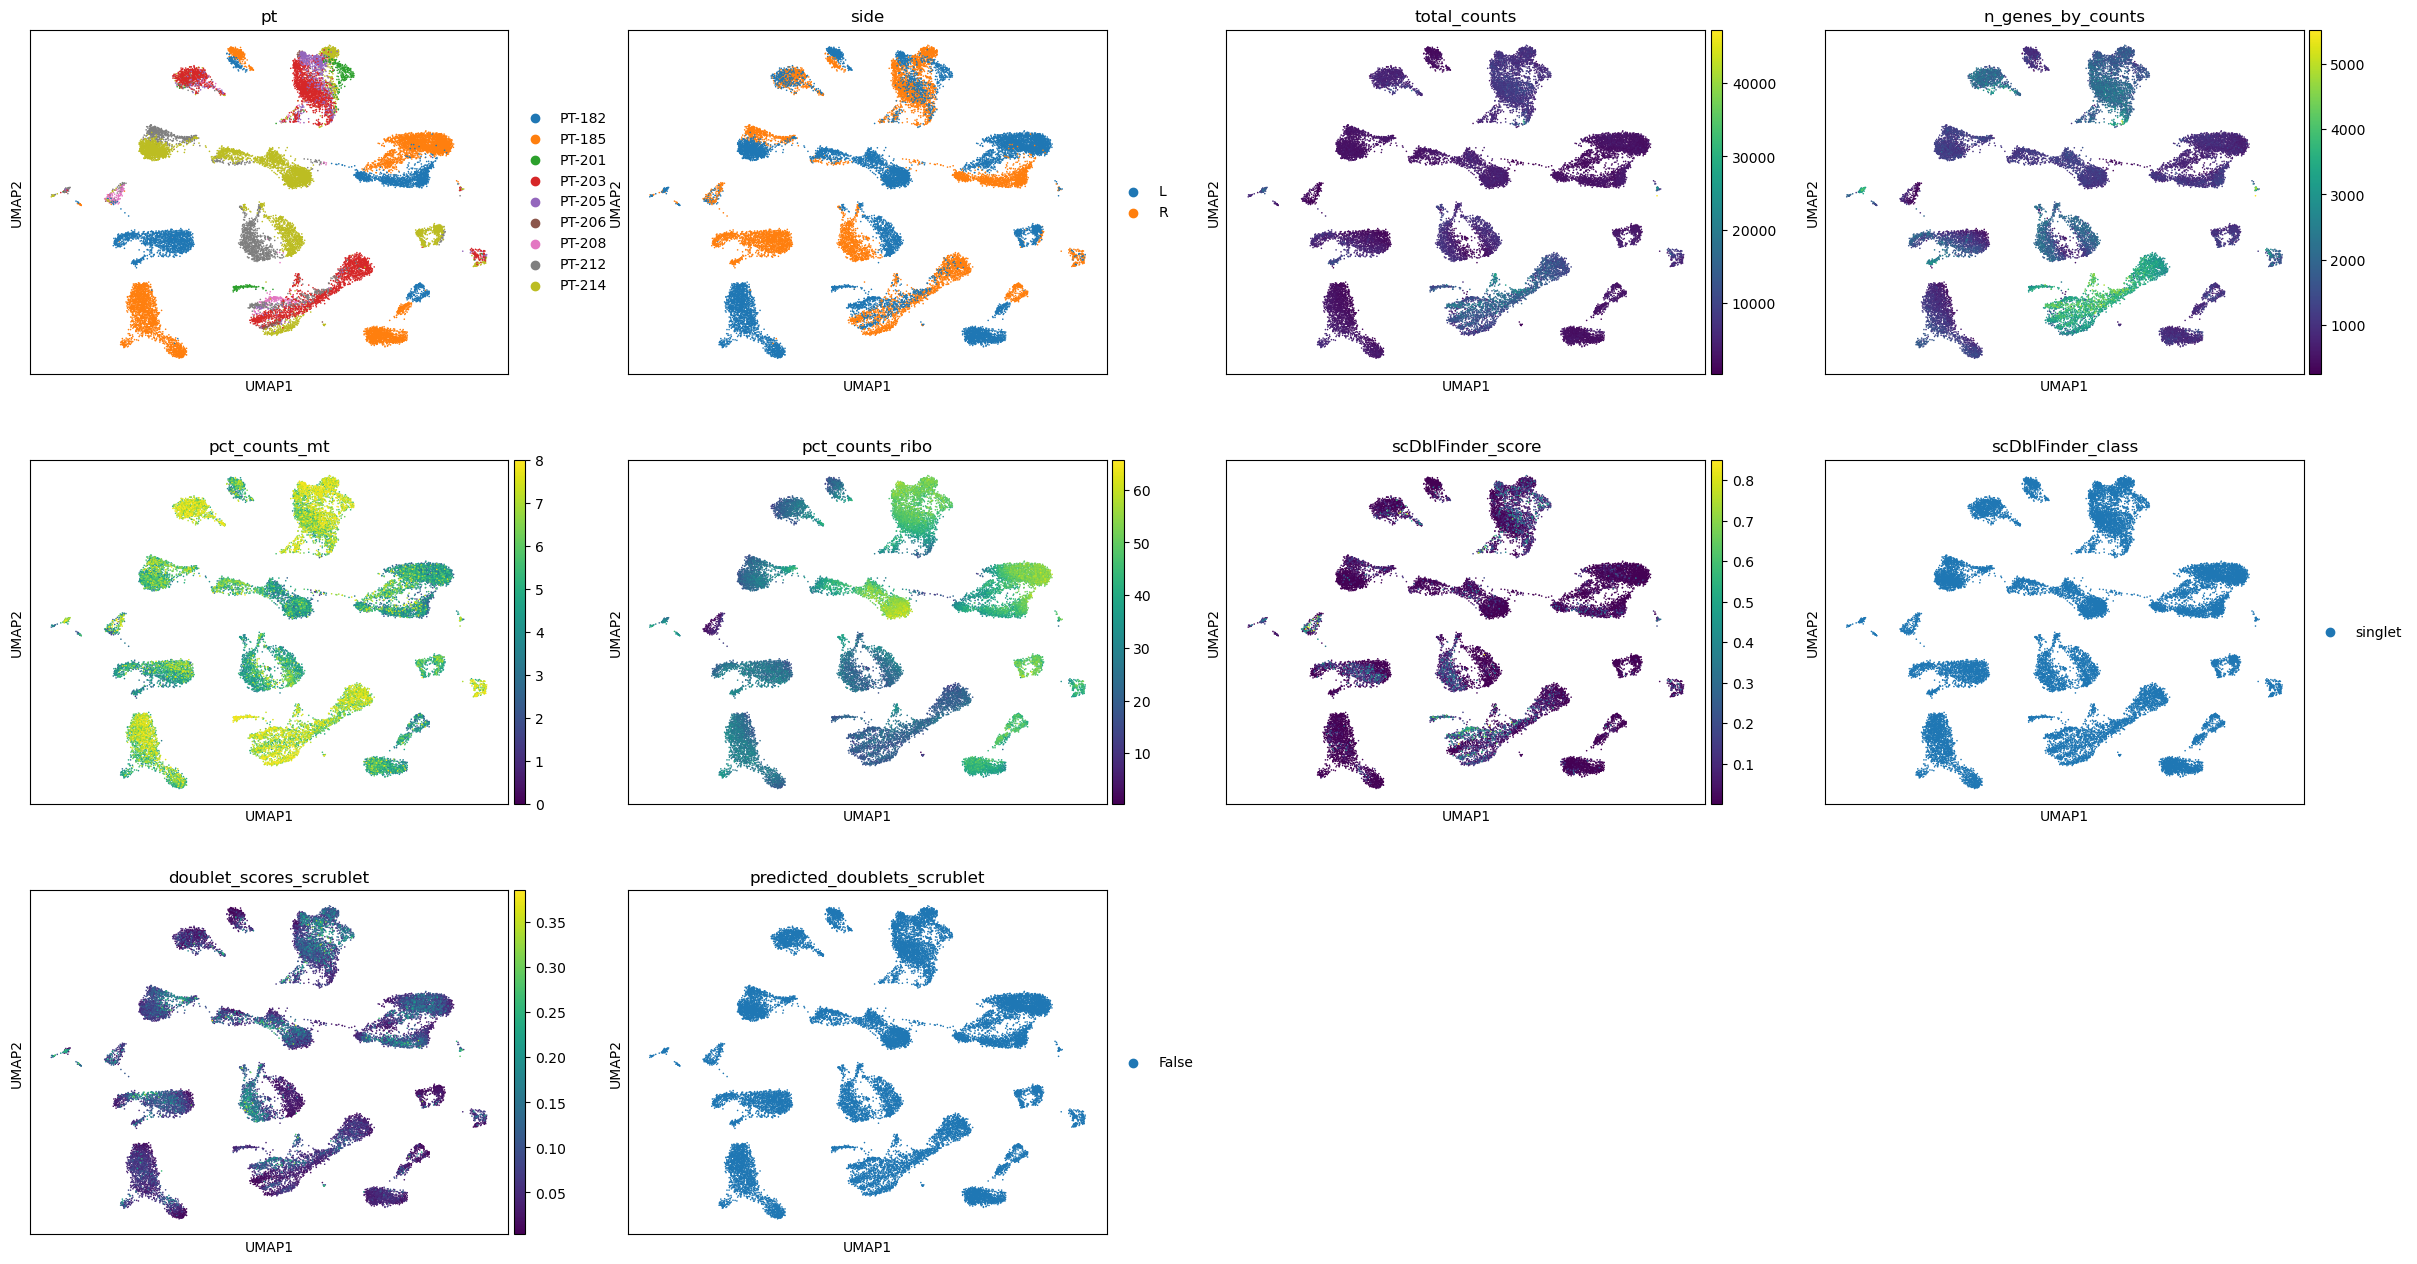

pt
side
total_counts
n_genes_by_counts
pct_counts_mt
pct_counts_ribo
scDblFinder_score
scDblFinder_class
doublet_scores_scrublet
predicted_doublets_scrublet
pt
pt
pct_counts_ribo
pct_counts_ribo
scDblFinder_score
scDblFinder_score


In [23]:
%matplotlib inline
adata_hvg.obs['scDblFinder_class'] = adata_hvg.obs['scDblFinder_class'].astype('str')
adata_hvg.obs['predicted_doublets_scrublet'] =adata_hvg.obs['predicted_doublets_scrublet'].astype('str')

labels = ['pt','side',"total_counts", "n_genes_by_counts", "pct_counts_mt", 'pct_counts_ribo', 'scDblFinder_score','scDblFinder_class','doublet_scores_scrublet', 'predicted_doublets_scrublet']
sc.pl.umap(adata_hvg, color=labels)
tabs = []

from bokeh.models import TabPanel, Tabs,ColorBar
from bokeh.plotting import show, output_file
from utils import interactive_embedding

for label in labels:
    tabs.append(TabPanel(child=interactive_embedding(adata_hvg, label), title=label))

for label in ['pt','pct_counts_ribo', 'scDblFinder_score']:

    tabs.append(TabPanel(child=interactive_embedding(adata_scvi, label), title=f"SCVI integration - {label}"))
    tabs.append(TabPanel(child=interactive_embedding(adata_harmony, label), title=f"Harmony integration - {label}"))

# tabs.append(TabPanel(child=interactive_embedding(adata_seurat, "total_counts"), title="Seurat FS"))
# tabs.append(TabPanel(child=interactive_embedding(adata_seuratv3, "total_counts"), title="Seurat3 FS"))
# tabs.append(TabPanel(child=interactive_embedding(adata_pearson, "total_counts"), title="Pearson FS"))

p = Tabs(tabs=tabs)
output_file(f"../QC_plots/integrated-blood.html")

# 
show(p)

In [ ]:
%matplotlib inline
adata_hvg.obs['scDblFinder_class'] = adata_hvg.obs['scDblFinder_class'].astype('str')
adata_hvg.obs['predicted_doublets_scrublet'] =adata_hvg.obs['predicted_doublets_scrublet'].astype('str')

labels = ['pt','side',"total_counts", "n_genes_by_counts", "pct_counts_mt", 'pct_counts_ribo', 'scDblFinder_score','scDblFinder_class','doublet_scores_scrublet', 'predicted_doublets_scrublet']
sc.pl.umap(adata_hvg, color=labels)
tabs = []

from bokeh.models import TabPanel, Tabs,ColorBar
from bokeh.plotting import show, output_file
from utils import interactive_embedding

for label in labels:
    tabs.append(TabPanel(child=interactive_embedding(adata_hvg, label), title=label))

for label in ['pt','pct_counts_ribo', 'scDblFinder_score']:

    tabs.append(TabPanel(child=interactive_embedding(adata_scvi, "pt"), title="SCVI integration"))
    tabs.append(TabPanel(child=interactive_embedding(adata_harmony, "pt"), title="Harmony integration"))

# tabs.append(TabPanel(child=interactive_embedding(adata_seurat, "total_counts"), title="Seurat FS"))
# tabs.append(TabPanel(child=interactive_embedding(adata_seuratv3, "total_counts"), title="Seurat3 FS"))
# tabs.append(TabPanel(child=interactive_embedding(adata_pearson, "total_counts"), title="Pearson FS"))

p = Tabs(tabs=tabs)
output_file(f"../QC_plots/integrated-scvi-blood.html")

# 


## Compare methods

In [ ]:
# Bioilogical conservation metrics need cell label or other key
#metrics_scvi = scib.metrics.metrics_fast(
#     adata, adata_scvi, batch_key, label_key, embed="X_scVI"
# )

In [24]:
import scib
# PCR_score: teh hogher the better, range 0-1
print("Unintegrated:", scib.metrics.pcr_comparison(adata_b1, adata_hvg, covariate="pt"), "\n")

print("Harmony",scib.metrics.pcr_comparison(adata_hvg, adata_harmony, covariate="pt", embed="X_pca_harmony"), "\n")
print("ScVI",scib.metrics.pcr_comparison(adata_hvg, adata_scvi, covariate="pt", embed="X_scVI"))

/Users/nicolebussola/anaconda3/envs/LBP_QC/lib/python3.8/site-packages/anndata/_core/anndata.py:453: PendingDeprecationWarning: The dtype argument will be deprecated in anndata 0.10.0
  warnings.warn(
/Users/nicolebussola/anaconda3/envs/LBP_QC/lib/python3.8/site-packages/anndata/_core/anndata.py:453: PendingDeprecationWarning: The dtype argument will be deprecated in anndata 0.10.0
  warnings.warn(


Unintegrated: 0.2026119695818432 



/Users/nicolebussola/anaconda3/envs/LBP_QC/lib/python3.8/site-packages/anndata/_core/anndata.py:453: PendingDeprecationWarning: The dtype argument will be deprecated in anndata 0.10.0
  warnings.warn(
/Users/nicolebussola/anaconda3/envs/LBP_QC/lib/python3.8/site-packages/anndata/_core/anndata.py:453: PendingDeprecationWarning: The dtype argument will be deprecated in anndata 0.10.0
  warnings.warn(


Harmony 0.6441925744456565 



/Users/nicolebussola/anaconda3/envs/LBP_QC/lib/python3.8/site-packages/anndata/_core/anndata.py:453: PendingDeprecationWarning: The dtype argument will be deprecated in anndata 0.10.0
  warnings.warn(
/Users/nicolebussola/anaconda3/envs/LBP_QC/lib/python3.8/site-packages/anndata/_core/anndata.py:453: PendingDeprecationWarning: The dtype argument will be deprecated in anndata 0.10.0
  warnings.warn(


ScVI 0.7845218232803247


# Clustering

In [25]:
import scvi
sc.tl.leiden(adata, key_added="leiden_res0_25", resolution=0.25)
sc.tl.leiden(adata, key_added="leiden_res0_5", resolution=0.5)
sc.tl.leiden(adata, key_added="leiden_res1", resolution=1.0)

NameError: name 'adata' is not defined

In [ ]:
sc.tl.leiden(adata)
sc.pl.umap(
    adata_b1,
    color=["leiden_res0_25", "leiden_res0_5", "leiden_res1"],
    legend_loc="on data",
)